<a href="https://colab.research.google.com/github/deepakk7195/IISC_CDS_DS/blob/capstone_project_group12/Inference_Notebook_to_Integrate_with_UI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from PIL import Image
import tensorflow as tf
import os
import sys
from tempfile import NamedTemporaryFile
from urllib.request import urlopen
from urllib.parse import unquote, urlparse
from urllib.error import HTTPError
from zipfile import ZipFile
import tarfile
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from google.colab.patches import cv2_imshow

#Preprocessing Function for Image preprocessing

In [ ]:
# Preprocessing function for the image for Phase2
def preprocess_image_retinograding(image):

   # # Convert the image to a NumPy array
    image_array = np.array(image)

   #Step 3: Convert RGB to Grayscale
    target_size =(299, 299)
    IMG_SIZE=299
    image_greyscale = cv2.cvtColor(image_array, cv2.COLOR_RGB2GRAY)
    resized_image = cv2.resize(image_greyscale, target_size)
    gaussian_image=cv2.addWeighted ( resized_image,4, cv2.GaussianBlur( resized_image , (0,0) , IMG_SIZE/10) ,-4 ,128)

    # # Convert the image to a NumPy array
    gausimage_array = np.array(gaussian_image)


    # Add a channel dimension if the image is grayscale
    if gausimage_array.ndim == 2:
        gausimage_array = np.expand_dims(gausimage_array, axis=-1)
        gausimage_array = np.repeat(gausimage_array, 3, axis=-1)  # Repeat to create 3 channels

    # Normalize pixel values to the range [0, 1]
    gausimage_array = gausimage_array.astype('float32') / 255.0

    # Add a batch dimension
    gausimage_array = np.expand_dims(gausimage_array, axis=0)

    #Convert image array to image
    #preprocessed_image = Image.fromarray(gausimage_array)

    return gausimage_array

In [ ]:
# Preprocessing function for the images in Phase 1a and 1b
def preprocess_image_disease_class(image):

   # # Convert the image to a NumPy array
    image_array = np.array(image)

    return image_array

#Preprocessing for batch creation

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import pandas as pd

In [ ]:
image_path = '/content/0_left.jpg'
image_path1 = '/content/1_left.jpg'

In [ ]:
def preprocess_binary_classification_Batch_Creation(image, image_path):

    # Create an ImageDataGenerator for validation and test data (no data augmentation)
    kvalid_test_datagen1 = ImageDataGenerator(rescale=1./255)

    # create the batch with the above image

    file_paths = [image_path, image_path1]
    labels = ['10','11']

    df_for_evaluate = pd.DataFrame({'filepath': file_paths, 'labels': labels})

    ktest_generator1 = kvalid_test_datagen1.flow_from_dataframe(
        dataframe=df_for_evaluate,
        x_col='filepath',
        y_col='labels',
        target_size=(224,224),
        shuffle=False,
        batch_size=8,
        class_mode='binary',
        color_mode = 'rgb'
    )

    return ktest_generator1


In [ ]:
r = preprocess_binary_classification_Batch_Creation('0_left.jpg', image_path)

Found 2 validated image filenames belonging to 2 classes.


# 1A,1B & Phase 2 Model Loading and subsequent prediction function

In [ ]:
# Loading Binary (DR / Non-DR (Sachin)) Model -
model1 = tf.keras.models.load_model("/content/best_efficientnet_model_binary_class.keras")

In [ ]:
model_DR_or_NonDR = model1
image_path = "/content/best_efficientnet_model_binary_class.keras"

In [ ]:
#Prediction Fucntion for Phase1 a

def predict_DR_or_NonDR(image):

    # Preprocess the input image
    #image = preprocess_image(image)
    #image_batch=preprocess_image_disease_class(image)

    image_batch = preprocess_binary_classification_Batch_Creation(image, image_path)

    # Make a prediction
    prediction = model_DR_or_NonDR.predict(image_batch)

    # Get the predicted class
    predicted_class_probability = np.argmax(prediction, axis=1)

    # print(predicted_class)

    # if we get 1, then DR,
    # if we get 0 then Non-DR

    # Convert to a result
    if predicted_class_probability < 0.5 :
        result = "No Diabetic Retinopathy"
    elif predicted_class_probability > 0.5 :
        result = "Diabetic Retinopathy"

    return result

In [ ]:
image = '/content/0_left.jpg'
a = predict_DR_or_NonDR(image)
print(a)

Found 1 validated image filenames belonging to 1 classes.


/usr/local/lib/python3.10/dist-packages/keras/src/legacy/preprocessing/image.py:920: UserWarning: Found 1 invalid image filename(s) in x_col="filepath". These filename(s) will be ignored.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step
No Diabetic Retinopathy


In [ ]:
# Loading Multi class disease classification model (1B - Sachin) -
model2 = tf.keras.models.load_model("/content/best_inceptionv3_model_multi_class.keras")
model_disease_class = model2

In [ ]:
image_path = "/content/best_inceptionv3_model_multi_class.keras"

In [27]:
def preprocess_multiclass_classification_Batch_Creation(image, image_path):

    # Create an ImageDataGenerator for validation and test data (no data augmentation)
    kvalid_test_datagen1 = ImageDataGenerator(rescale=1./255)

    # create the batch with the above image

    file_paths = [image_path, image_path1]
    labels = ['10','11']

    df_for_evaluate = pd.DataFrame({'filepath': file_paths, 'labels': labels})

    ktest_generator1 = kvalid_test_datagen1.flow_from_dataframe(
        dataframe=df_for_evaluate,
        x_col='filepath',
        y_col='labels',
        target_size=(299,299),
        shuffle=False,
        batch_size=8,
        class_mode='binary',
        color_mode = 'rgb'
    )

    return ktest_generator1


In [36]:
#Prediction Function for Phase1 b
def predict_disease_class(image):

    # Preprocess the input image
    #image = preprocess_image(image)
    image_batch = preprocess_multiclass_classification_Batch_Creation(image,image_path)

    # Make a prediction
    prediction = model_disease_class.predict(image_batch)

    # Get the predicted class
    predicted_class = np.argmax(prediction, axis=1)  # For multi-class problems
    print(predicted_class[0])

    # Convert to a result (check with Sachin for the codes for each predicted class)
    if predicted_class[0] == 0:
        result = "Normal Eye"
    elif predicted_class[0] == 1:
        result = "Glaucoma"
    elif predicted_class[0] == 2:
        result = "Cataract"
    elif predicted_class[0] == 3:
        result = "AMD"
    elif predicted_class[0] == 4:
        result = "Hypertension"
    elif predicted_class[0] == 5:
        result = "Myopia"
    return result

In [37]:
image = '/content/0_left.jpg'
b = predict_disease_class(image)
print(b)

Found 2 validated image filenames belonging to 2 classes.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step
0
Normal Eye


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


In [38]:
# Loading Retinopathy Grading (Phase 2) Model (Stan) -
model_retino_grading = tf.keras.models.load_model("/content/model-InceptionV3-Ver12a.h5")

In [39]:
#Prediction Function for Phase2
def predict_diabetic_retinopathy_grading(image):

    # Preprocess the input image
    #image = preprocess_image(image)
    image_batch=preprocess_image_retinograding(image)

    # Make a prediction
    prediction = model_retino_grading.predict(image_batch)

    # Get the predicted class
    predicted_class = np.argmax(prediction, axis=1)  # For multi-class problems

    # Convert to a result
    if predicted_class == 0:
        result = "No Diabetic Retinopathy"
    elif predicted_class == 1:
        result = "Mild Diabetic Retinopathy"
    elif predicted_class == 2:
        result = "Moderate Diabetic Retinopathy"
    elif predicted_class == 3:
        result = "Severe Diabetic Retinopathy"
    elif predicted_class == 4:
        result = "Proliferative Diabetic Retinopathy"

    return result

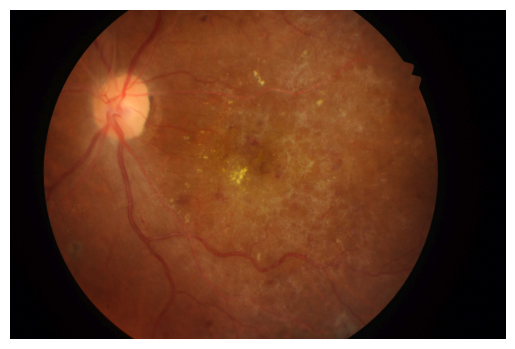

In [40]:
from PIL import Image
image_path = '/content/0_left.jpg'  # You can provide the path to an image file
image = Image.open(image_path)
plt.imshow(image)
plt.axis('off')  # Hide axes
plt.show()

In [ ]:
# image_batch=preprocess_image(image)

In [41]:
predict_diabetic_retinopathy_grading(image)

1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step


'No Diabetic Retinopathy'

#Gradio Interface

In [ ]:
pip install --upgrade gradio

In [42]:
import gradio as gr
import random
from PIL import Image

# Define classes for Non-DR disease classification
disease_classes = [
    "Normal",
    "Glaucoma",
    "AMD",
    "Cataract",
    "Hypertension",
    "Myopia"
]

# Global variables to store shared data
shared_image = None
shared_dr_or_non_dr = None


# Step 1: DR vs. Non-DR Classification
def classify_dr_non_dr(image):
    global shared_image, shared_dr_or_non_dr
    if image is None:
        return "Error: No image provided"

    prediction = predict_DR_or_NonDR(image)
    shared_dr_or_non_dr = prediction
    return prediction

# Step 2: Non-DR Disease Classification
def classify_non_dr(image, actual_label):
    if image is None or actual_label not in disease_classes:
        return "Error: Invalid input", "Error: Invalid input"

    predicted_class = predict_disease_class(image)
    return predicted_class, actual_label

# Step 3: Retinopathy Grading
def grade_retinopathy(image, grading_label):
    predicted_grade = predict_diabetic_retinopathy_grading(image)
    return predicted_grade, grading_label

###########

# Tab 1: DR vs. Non-DR Classification
tab1 = gr.Interface(
    fn=classify_dr_non_dr,
    inputs=gr.Image(type="pil", label="Upload Fundus Image"),
    outputs=gr.Textbox(label="Classification: DR or Non-DR"),
    title="Step 1: DR vs. Non-DR Classification",
    description="Upload a fundus image to classify it as Diabetic Retinopathy or Non-Diabetic Retinopathy."
)

# Tab 2: Non-DR Disease Classification
with gr.Blocks() as tab2:
    with gr.Row():
        non_dr_image = gr.Image(type="pil", label="Upload Fundus Image (if applicable)")
        actual_label_input = gr.Dropdown(choices=disease_classes, label="Select Actual Disease Label")
    with gr.Row():
        predict_button = gr.Button("Classify Non-DR Disease")
    with gr.Row():
        predicted_class = gr.Textbox(label="Predicted Disease Class")
        selected_label = gr.Textbox(label="Actual Disease Label Selected")

    # Function to classify Non-DR disease
    def handle_non_dr_classification(image, actual_label):
        global shared_image, shared_dr_or_non_dr
        if shared_dr_or_non_dr != "Non-Diabetic Retinopathy":
            return "Error: Image not classified as Non-Diabetic Retinopathy", "Error: Invalid input"
        if image is None:
            image = shared_image  # Use shared image if no new image is uploaded
        return classify_non_dr(image, actual_label)

    predict_button.click(
        handle_non_dr_classification,
        inputs=[non_dr_image, actual_label_input],
        outputs=[predicted_class, selected_label]
    )

# Tab 3: DR Grading
with gr.Blocks() as tab3:
    with gr.Row():
        img_option = gr.Radio(["Use Same Image", "Upload New Image"], value="Use Same Image", label="Image Source")
    with gr.Row():
        image_input = gr.Image(type="pil", label="Upload Fundus Image (if applicable)", visible=False)
    with gr.Row():
        grade_label = gr.Dropdown(choices=["0", "1", "2", "3", "4"], label="Select Retinopathy Grade")
    with gr.Row():
        predict_button = gr.Button("Grade Retinopathy")
    with gr.Row():
        predicted_grade = gr.Textbox(label="Predicted Grade")
        selected_grade = gr.Textbox(label="Selected Grade")

    # Toggle image input visibility
    def toggle_image_input(image_source):
        if image_source == "Use Same Image":
            return gr.update(visible=False)
        return gr.update(visible=True)

    img_option.change(toggle_image_input, img_option, image_input)

    # Handle DR grading
    def handle_retinopathy_grading(image, grade):
        global shared_image, shared_dr_or_non_dr
        if shared_dr_or_non_dr != "Diabetic Retinopathy":
            return "Error: Image not classified as Diabetic Retinopathy", "Error: Invalid input"
        if image is None:
            image = shared_image  # Use shared image if no new image is uploaded
        return grade_retinopathy(image, grade)

    predict_button.click(
        handle_retinopathy_grading,
        inputs=[image_input, grade_label],
        outputs=[predicted_grade, selected_grade]
    )

# Combine the three tabs into a single app
demo = gr.TabbedInterface(
    [tab1, tab2, tab3],
    ["DR vs. Non-DR Classification", "Non-DR Disease Classification", "Retinopathy Grading"]
)

# Launch the app
demo.launch(share=True)


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://8d78125b42795dbcc3.gradio.live

This share link expires in 72 hours. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
# import gradio as gr
# import random

# # Define classes for the first tab (disease classification)
# disease_classes = [
#     "Normal",
#     "Glaucoma",
#     "Diabetic Retinopathy",
#     "Macular Degeneration",
#     "Hypertensive Retinopathy",
#     "Cataract",
#     "Retinal Detachment",
#     "Optic Neuritis"
# ]

# # Define a global variable to store the image from the first tab
# shared_image = None

# # Dummy model for disease classification
# def classify_disease(image, actual_label):
#     global shared_image
#     shared_image = image  # Save the image for use in the second tab
#     if image is None or actual_label not in disease_classes:
#         return "Error: Invalid input", "Error: Invalid input"

#     predicted_class = random.choice(disease_classes)
#     return predicted_class, actual_label

# # Dummy model for retinopathy grading
# def grade_retinopathy(image, grading_label):
#     # if image is None or grading_label not in ["0", "1", "2", "3", "4"]:
#     #     return "Error: Invalid input", "Error: Invalid input"

#     # predicted_grade = random.choice(["0", "1", "2", "3", "4"])
#     predicted_grade = predict_diabetic_retinopathy_grading(image)
#     return predicted_grade, grading_label

# # First tab interface (Disease Classification)
# tab1 = gr.Interface(
#     fn=classify_disease,
#     inputs=[
#         gr.Image(type="pil", label="Upload Fundus Image"),
#         gr.Dropdown(choices=disease_classes, label="Select Actual Disease Label")
#     ],
#     outputs=[
#         gr.Textbox(label="Predicted Class"),
#         gr.Textbox(label="Actual Label Selected")
#     ],
#     title="Disease Classification",
#     description="Upload a fundus image and classify it into one of the disease categories."
# )

# # Second tab interface (Retinopathy Grading)
# with gr.Blocks() as tab2:
#     with gr.Row():
#         img_option = gr.Radio(["Use Same Image", "Upload New Image"], value="Upload New Image", label="Image Source")
#     with gr.Row():
#         image_input = gr.Image(type="pil", label="Upload Fundus Image (if applicable)", visible=True)
#     with gr.Row():
#         grade_label = gr.Dropdown(choices=["0", "1", "2", "3", "4"], label="Select Retinopathy Grade")
#     with gr.Row():
#         predict_button = gr.Button("Classify Retinopathy")
#     with gr.Row():
#         predicted_grade = gr.Textbox(label="Predicted Grade")
#         selected_grade = gr.Textbox(label="Selected Grade")

#     # Function to toggle image input visibility
#     def toggle_image_input(image_source):
#         if image_source == "Use Same Image":
#             return gr.update(visible=False)  # Hide input
#         return gr.update(visible=True)  # Show input

#     img_option.change(toggle_image_input, img_option, image_input)

#     # Function to handle retinopathy grading
#     def handle_retinopathy(image, grade):
#         global shared_image
#         if image is None:  # Use shared image if "Use Same Image" is selected
#             image = shared_image
#         return grade_retinopathy(image, grade)

#     predict_button.click(handle_retinopathy, [image_input, grade_label], [predicted_grade, selected_grade])

# # Combine the two tabs
# demo = gr.TabbedInterface([tab1, tab2], ["Disease Classification", "Retinopathy Grading"])

# # Launch the app
# demo.launch(share=True)


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://333f9c5d099b171658.gradio.live

This share link expires in 72 hours. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


#Phase 1 Inferencing Code (CNN Model) -1a,1b
#Phase 1 Inferencing COde (Vision Transformer)
#Phase 2 Inferencing Code (CNN Model)
#Phase 2 Inferencing COde (Vision Transformer)
# Gradio UI Code

phase2 predict --done CNN
Predict 1a, predict 1b